# NIAID API Resource Network Graph

Interactive force-directed network visualizing relationships between NIAID data resources.

**How to use:**
- Run the cell below — it writes `niaid_network.html` alongside this notebook and renders it inline
- **Hover** any node to see full name, API style, and access details
- **Click** a node to open the resource URL in a new tab
- **Drag** nodes to rearrange; **scroll/pinch** to zoom
- Use the **group filter buttons** to isolate a division

**Edge types:**

| Colour | Meaning |
|--------|---------|
| Purple | Same organisational group |
| Green  | NDE-registered (connected to NDE hub) |
| Gold   | GDS-registered |
| Dashed orange | Shared API style across groups |

✅ Graph saved as 'niaid_api_network.png'


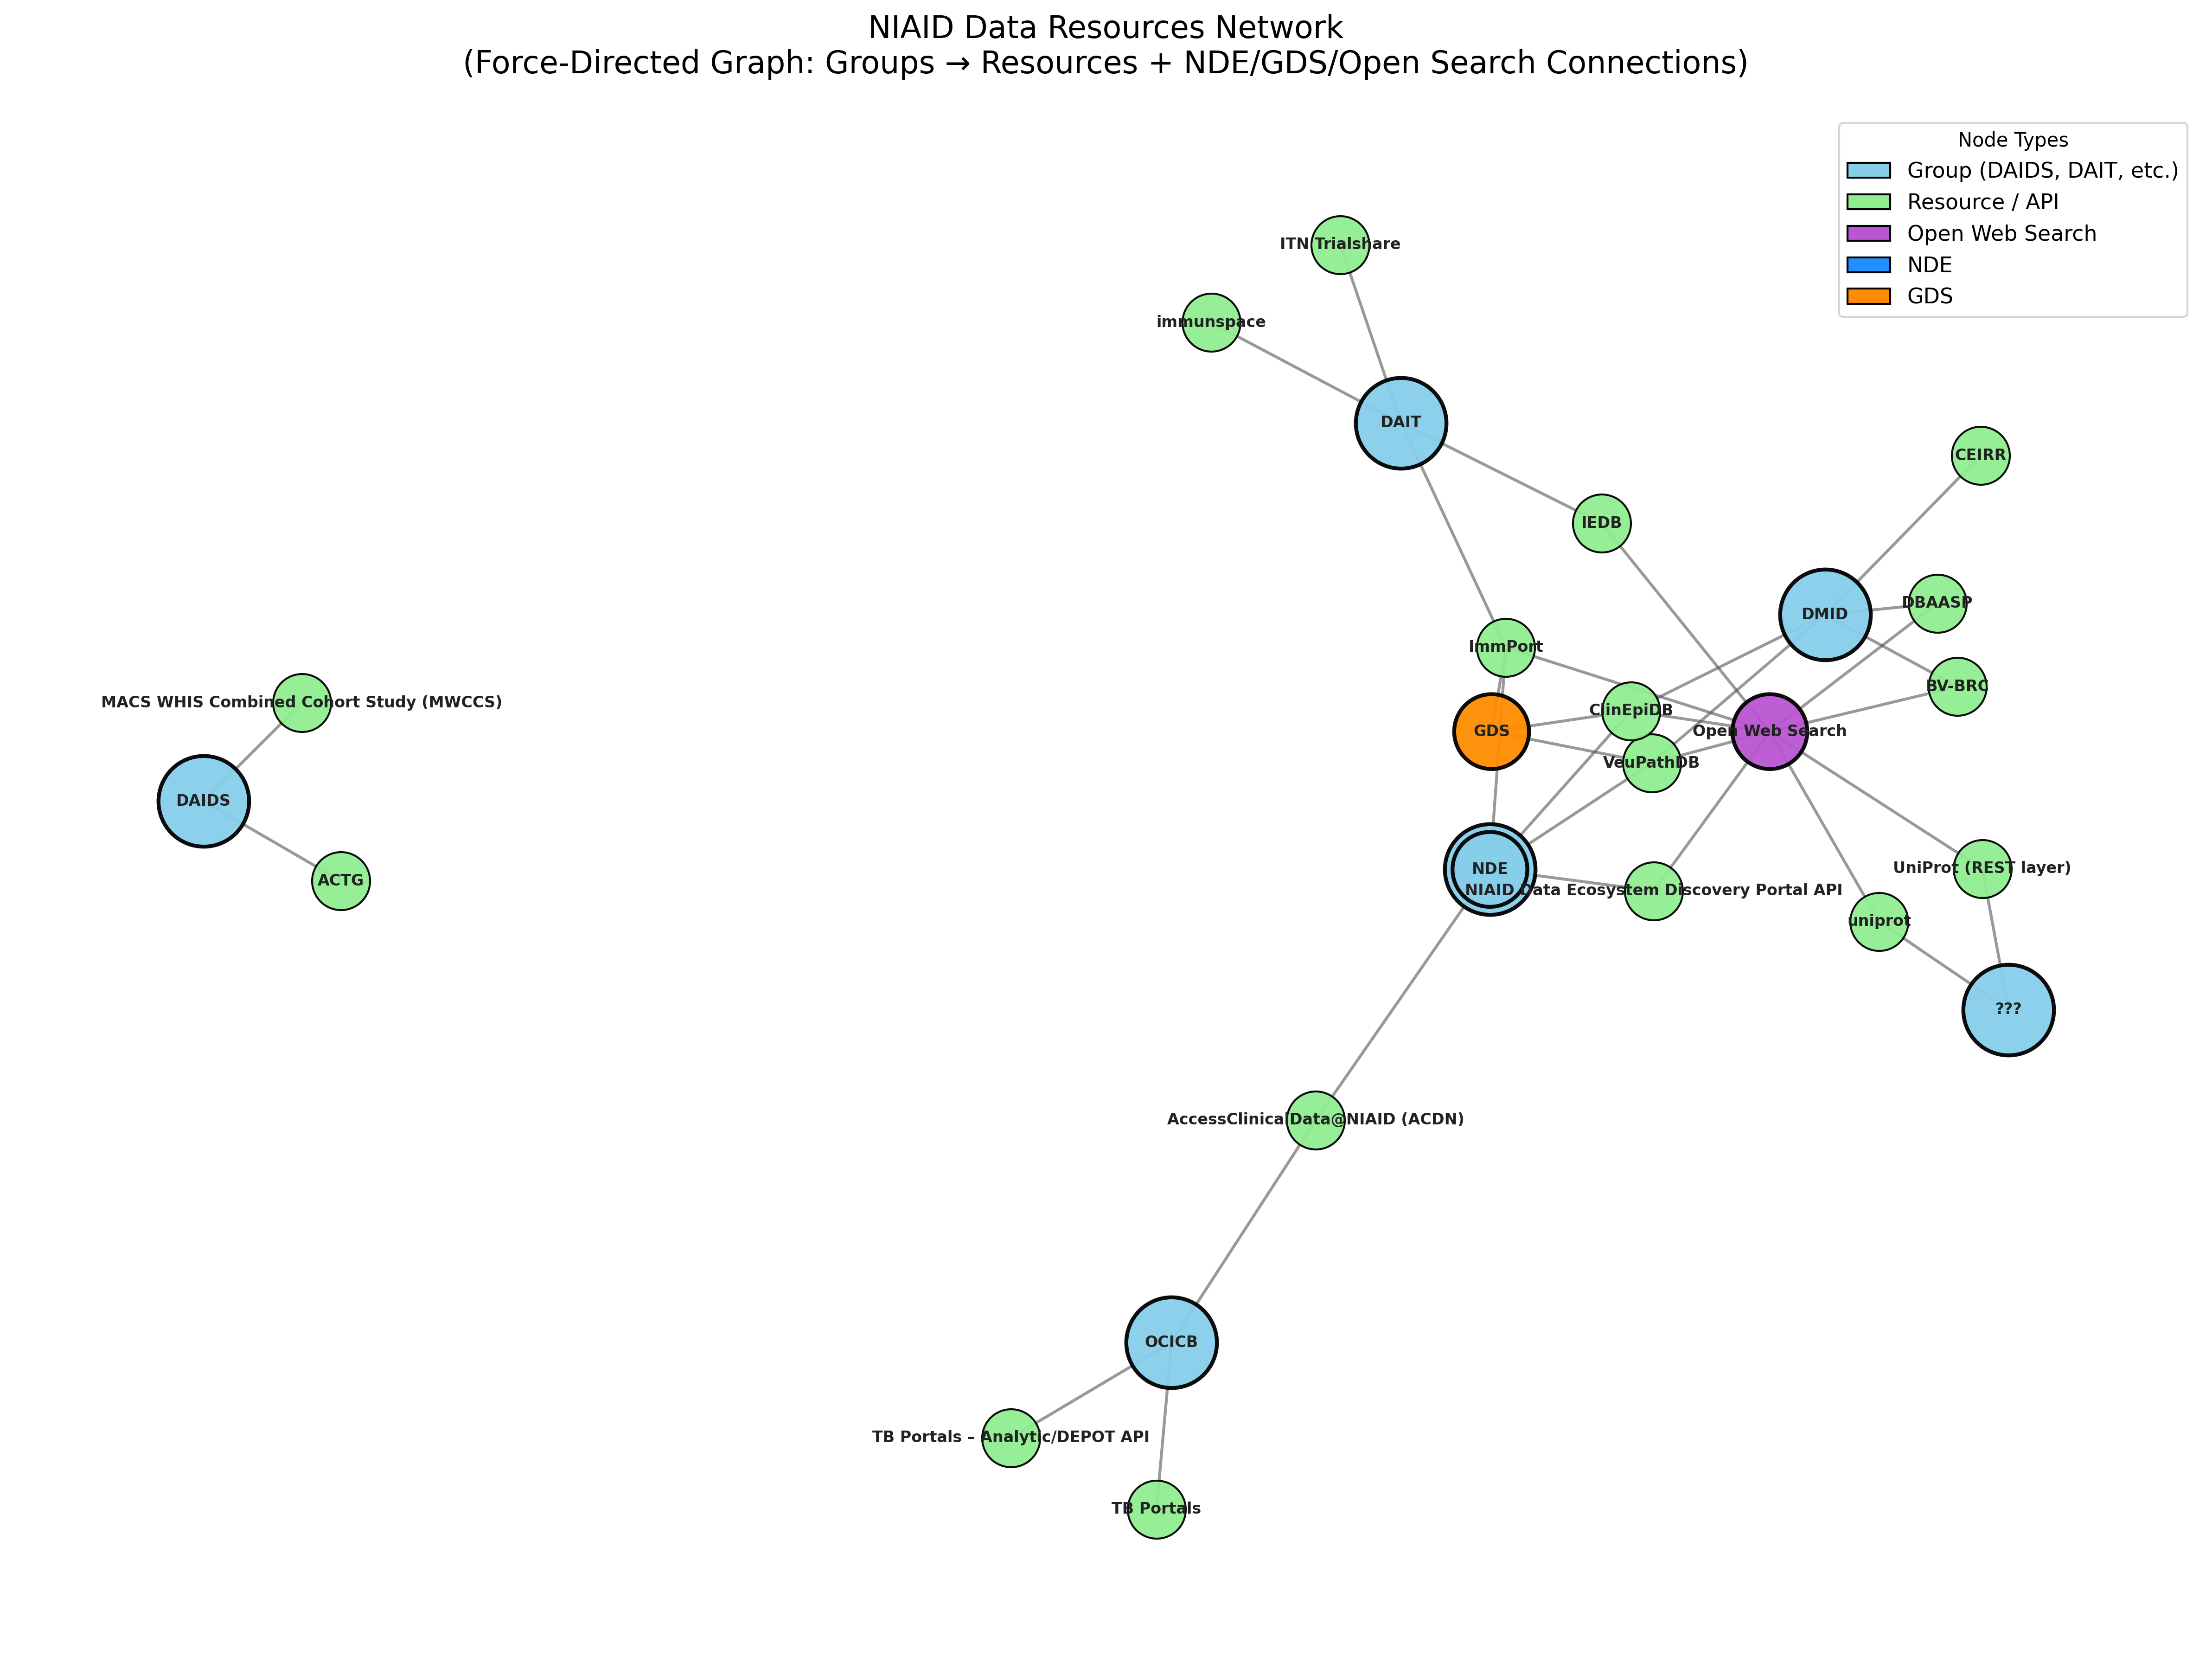

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =============================================
# FULL SELF-CONTAINED SCRIPT
# NIAID Data Resources Network - Force-Directed Graph
# =============================================

# 1. Raw data from your markdown table (all 17 rows, exactly as provided)
data = [
    {"group": "DAIDS", "name": "MACS WHIS Combined Cohort Study (MWCCS)", "open_search": "", "nde": "", "gds": ""},
    {"group": "DAIDS", "name": "ACTG", "open_search": "", "nde": "", "gds": ""},
    {"group": "DAIT", "name": "IEDB", "open_search": "X", "nde": "", "gds": ""},
    {"group": "DAIT", "name": "ImmPort", "open_search": "X", "nde": "NDE URL", "gds": "GDS"},
    {"group": "DAIT", "name": "ITN Trialshare", "open_search": "", "nde": "", "gds": ""},
    {"group": "DAIT", "name": "immunspace", "open_search": "", "nde": "", "gds": ""},
    {"group": "DMID", "name": "VeuPathDB", "open_search": "X", "nde": "NDE URL", "gds": "GDS"},
    {"group": "DMID", "name": "BV-BRC", "open_search": "X", "nde": "", "gds": ""},
    {"group": "DMID", "name": "CEIRR", "open_search": "", "nde": "", "gds": ""},
    {"group": "DMID", "name": "ClinEpiDB", "open_search": "X", "nde": "NDE URL", "gds": "GDS"},
    {"group": "OCICB", "name": "AccessClinicalData@NIAID (ACDN)", "open_search": "", "nde": "NDE URL", "gds": ""},
    {"group": "OCICB", "name": "TB Portals", "open_search": "", "nde": "", "gds": ""},
    {"group": "???", "name": "uniprot", "open_search": "X", "nde": "", "gds": ""},
    {"group": "DMID", "name": "DBAASP", "open_search": "X", "nde": "", "gds": ""},
    {"group": "OCICB", "name": "TB Portals – Analytic/DEPOT API", "open_search": "", "nde": "", "gds": ""},
    {"group": "NDE", "name": "NIAID Data Ecosystem Discovery Portal API", "open_search": "X", "nde": "NDE URL", "gds": ""},
    {"group": "???", "name": "UniProt (REST layer)", "open_search": "X", "nde": "", "gds": ""},
]

# 2. Build the graph
G = nx.Graph()

# Feature nodes (central ecosystem connectors)
G.add_node("Open Web Search", type="feature", color="#BA55D3", size=1500)
G.add_node("NDE",            type="feature", color="#1E90FF", size=1500)
G.add_node("GDS",            type="feature", color="#FF8C00", size=1500)

# Group nodes (large hubs)
groups = set(row["group"] for row in data)
for g in groups:
    G.add_node(g, type="group", color="#87CEEB", size=2200)

# Resource nodes + edges
for row in data:
    res = row["name"]
    G.add_node(res, type="resource", color="#90EE90", size=900)

    # Resource → Group
    G.add_edge(row["group"], res)

    # Feature connections
    if row["open_search"] == "X":
        G.add_edge(res, "Open Web Search")
    if row["nde"] == "NDE URL":
        G.add_edge(res, "NDE")
    if row["gds"] == "GDS":
        G.add_edge(res, "GDS")

# 3. Force-directed layout (spring layout = physics simulation)
pos = nx.spring_layout(G, seed=42, k=0.65, iterations=120)

# 4. Draw the graph
plt.figure(figsize=(16, 12), dpi=300)
plt.title("NIAID Data Resources Network\n(Force-Directed Graph: Groups → Resources + NDE/GDS/Open Search Connections)",
          fontsize=16, pad=20)

# Draw nodes by type
nx.draw_networkx_nodes(G, pos,
                       nodelist=[n for n, d in G.nodes(data=True) if d.get("type") == "group"],
                       node_color="#87CEEB", node_size=2200, alpha=0.95, edgecolors="black", linewidths=2)

nx.draw_networkx_nodes(G, pos,
                       nodelist=[n for n, d in G.nodes(data=True) if d.get("type") == "resource"],
                       node_color="#90EE90", node_size=900, alpha=0.95, edgecolors="black", linewidths=1)

nx.draw_networkx_nodes(G, pos,
                       nodelist=["Open Web Search", "NDE", "GDS"],
                       node_color=[d["color"] for n, d in G.nodes(data=True) if n in ["Open Web Search", "NDE", "GDS"]],
                       node_size=1500, alpha=0.95, edgecolors="black", linewidths=2)

# Edges
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.6, edge_color="#555555")

# Labels (resource names are long, so smaller font + slight offset)
labels = {}
for node in G.nodes():
    if node in ["Open Web Search", "NDE", "GDS"]:
        labels[node] = node
    elif node in groups:
        labels[node] = node
    else:
        # shorten very long names for readability (same as the image you saw)
        short = node[:45] + "..." if len(node) > 45 else node
        labels[node] = short

nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight="bold", font_color="#222222")

# Legend
legend_elements = [
    Patch(facecolor="#87CEEB", edgecolor="black", label="Group (DAIDS, DAIT, etc.)"),
    Patch(facecolor="#90EE90", edgecolor="black", label="Resource / API"),
    Patch(facecolor="#BA55D3", edgecolor="black", label="Open Web Search"),
    Patch(facecolor="#1E90FF", edgecolor="black", label="NDE"),
    Patch(facecolor="#FF8C00", edgecolor="black", label="GDS"),
]
plt.legend(handles=legend_elements, loc="upper right", fontsize=11, title="Node Types")

plt.axis("off")
plt.tight_layout()

# Save high-resolution PNG (same style as the one you saw)
plt.savefig("niaid_api_network.png", dpi=300, bbox_inches="tight")
print("✅ Graph saved as 'niaid_api_network.png'")

# Optional: show in window (uncomment if running locally)
plt.show()